# Get grounding line mask

In [1]:
import numpy as np
import xarray as xr
from matplotlib import pylab as plt
import pandas as pd
import os

## Define filepaths (assuming all data exist in basepath)

In [2]:
# dirPath = '../mnt/ncihome/ismip6_2300'
dirPath = '../local/ismip6_2300'

metadata = pd.read_csv('Metadata.txt')


expFilter = ['expAE05'] # specify an experiment
# gridFilter = ['04', '4', '8', '_08'] 
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove

models = metadata.loc[( metadata['Experiment'].isin(expFilter)) &
        ~(metadata['fileID'].isin(removeFileID)),]

# only get local models: delete below line when running on cluster
models = models.loc[models['fileID'].isin(['PIK_PISM'])] 

# initialize empty dataframe to store processed_data, containing file, pathtofile, experiment, model, grid
processed_data = pd.DataFrame(columns=['basefile', 'libmassbfflfile', 'maskfile' , 'thermalforcingfile',
                                 'path', 'Experiment', 'Model', 'Grid'])

for i in range(models.shape[0]):

    modelPath = models.iloc[i].fileID
    exp = models.iloc[i].Experiment
    modelFiles = os.listdir(dirPath + '/' + modelPath)
    expDirPos = [i for i, dirName in enumerate(modelFiles) if dirName.startswith(exp)]

    

    # For each relevant directory, loop
    for expdir_subgrid in expDirPos:
        expDir = modelFiles[expdir_subgrid]
        expFiles = os.listdir(dirPath + '/' + modelPath + '/' + expDir)

        # Get grid size from expDir: format expAE01_04 where 04 is the grid size and convert to int
        grid = int(expDir.split('_')[1])
    
        # Find position of relevant files
        draftPos = [i for i, fileName in enumerate(expFiles) if fileName.startswith('base')]
        meltPos = [i for i, fileName in enumerate(expFiles) if fileName.startswith('libmassbffl')]
        maskPos = [i for i, fileName in enumerate(expFiles) if fileName.startswith('sftflf')]
        thermalPos = [i for i, fileName in enumerate(expFiles) if fileName.startswith('shelf_thermalforcing')]
    
        # draftData = xr.open_dataset(files[draftPos])
        # meltData = xr.open_dataset(files[meltPos])

        #save into processed_data: use concat not append
        processed_data = pd.concat([processed_data, pd.DataFrame({'basefile': expFiles[draftPos[0]], 
                                                                  'libmassbfflfile': expFiles[meltPos[0]], 
                                                                  'maskfile': expFiles[maskPos[0]],
                                                                    'thermalforcingfile': expFiles[thermalPos[0]],
                                                                  'path': dirPath + '/' + modelPath + '/' + expDir,
                                                                  'Experiment': exp,
                                                                  'Model': modelPath,
                                                                  'Grid': grid}, index=[0])], ignore_index=True)
        


        # ## DO STUFF HERE
        # print(expFiles[draftPos[0]])
        # print(grid)
        
        



In [3]:
processed_data

,basefile,libmassbfflfile,maskfile,thermalforcingfile,path,Experiment,Model,Grid
0,base_AIS_PIK_PISM_expAE02.nc,libmassbffl_AIS_PIK_PISM_expAE02.nc,sftflf_AIS_PIK_PISM_expAE02.nc,shelf_thermalforcingBin_AIS_PIK_PISM_expAE02.nc,../local/ismip6_2300/PIK_PISM/expAE05_08,expAE05,PIK_PISM,8


In [4]:
def getBoundaryCells(mask):

    #### creating boarder cells  around antartic ice mask, e.g. first floating cell or open ocean
    boarder_mask_float = np.zeros(mask.shape)
    difm =mask[1:,:] - mask[:-1,:]
    m_1 = difm ==1
    m_minus1 = difm == -1
    boarder_mask_float[:-1,][m_1]=1
    boarder_mask_float[1:,][m_minus1]=1

    difu = mask[:,1:] - mask[:,:-1]
    m_1u = difu ==1
    m_minus1u = difu == -1
    boarder_mask_float[:,:-1][m_1u]=1
    boarder_mask_float[:,1:][m_minus1u]=1
    return boarder_mask_float

In [5]:
def getGLMask(mask, nCells):
    
    m = np.zeros(mask.values.shape)
    m[mask.values==0]=1
    new_m = m.copy()

    for i in range(nCells):
        boundaryCells = getBoundaryCells(new_m)
        new_m[boundaryCells == 1] = 1
    
        shelfGL = (boundaryCells == 1) & (mask.values>0)
    
    return shelfGL
    


In [6]:


## Load sector files
sectors = {}
for grid in processed_data.Grid.unique():
    sectors[grid] = xr.open_dataset(dirPath+ '/masks/sectors_' + str(grid) + 'km.nc')

# Get sector and region numbers
regNums = np.unique(sectors[list(sectors.keys())[0]].regions).astype(int)
secNums = np.unique(sectors[list(sectors.keys())[0]].sectors).astype(int)




In [42]:
import os

outputpath = '../local/ismip6_hackathon/ComputedScalars/'

names_to_save = ['groundingline_depth', 'groundling_bmb', 'groundingline_thermal_forcing']




## Loop through processed_data and load each mask in
for i in range(processed_data.shape[0]):


    ds_bmb = xr.Dataset()
    ds_draft = xr.Dataset()
    ds_tf = xr.Dataset()

    model = processed_data.iloc[i].Model
    exp = processed_data.iloc[i].Experiment
    grid = processed_data.iloc[i].Grid

    dirtosave = outputpath + exp
    filename_bmb = 'computed_groundingline_bmb_AIS_' + model + '_' + exp + '.nc'
    filename_draft = 'computed_groundingline_depth_AIS_' + model + '_' + exp + '.nc'
    filename_tf = 'computed_groundingline_thermal_forcing_AIS_' + model + '_' + exp + '.nc'
    

    maskData = xr.open_dataset(processed_data.iloc[i].path + '/' + processed_data.iloc[i].maskfile)
    BmbData = xr.open_dataset(processed_data.iloc[i].path + '/' + processed_data.iloc[i].libmassbfflfile)
    draftData = xr.open_dataset(processed_data.iloc[i].path + '/' + processed_data.iloc[i].basefile)
    tfData = xr.open_dataset(processed_data.iloc[i].path + '/' + processed_data.iloc[i].thermalforcingfile)

    
    # remove any values after 2300-01-01
    for data in (maskData, BmbData, draftData, tfData):
        data = data.sel(time=slice(None, '2300-12-30'))


    glMask = maskData.sftflf.copy() # Pre-assign output size
    glBmb = BmbData.libmassbffl.copy() # Pre-assign output size
    glDraft = draftData.base.copy() # Pre-assign output size
    glTf = tfData.thermalforcing_bin.copy() # Pre-assign output size
    nT = maskData.time.size # Get number of timesteps

    # Save time
    for ds in (ds_bmb, ds_draft, ds_tf):
        ds.coords['time'] = maskData.time


    # How many cells should be used for the GL corridor
    nCells = 16//grid
    
    # Loop over each timestep, isolate the mask, sample parameters
    glDraftValues = draftData.base.values
    bmbTs = np.zeros(nT)
    draftTs = np.zeros(nT)
    tfTs = np.zeros(nT)

   
    # Antarctica wide
    for j in range(nT):
        mask = maskData.sftflf.isel(time=j)
        maskT = getGLMask(mask, nCells)
        glBmb[j,:,:] = xr.where(maskT == 1, BmbData.libmassbffl.isel(time = j), np.nan)
        glDraft[j,:,:] = xr.where(maskT == 1, glDraftValues[j], np.nan)
        glTf[j,:,:] = xr.where(maskT == 1, tfData.thermalforcing_bin.isel(time = j), np.nan)

        bmbTs[j] = float(glBmb.isel(time = j).mean())
        draftTs[j] = float(glDraft.isel(time=j).mean())
        tfTs[j] = float(glTf.isel(time=j).mean())

    # Save Antarctica wide
    
    ds_bmb['groundingline_bmb_antarctica'] = xr.DataArray(bmbTs, dims=['time'])
    ds_draft['groundingline_depth_antarctica'] = xr.DataArray(draftTs, dims=['time'])
    ds_tf['groundingline_thermal_forcing_antarctica'] = xr.DataArray(tfTs, dims=['time'])

    

    
    sectFrame = sectors[grid]
    for sec in secNums:
        secMask = xr.where(sectFrame.sectors == sec, 1, np.nan)
        secBmb = xr.where(secMask == 1, glBmb, np.nan)
        secDraft = xr.where(secMask == 1, glDraft, np.nan)
        secTf = xr.where(secMask == 1, glTf, np.nan)

        bmb = np.zeros(nT)
        draft = np.zeros(nT)
        tf = np.zeros(nT)
        for j in range(nT):
            bmb[j] = float(secBmb.isel(time = j).mean())
            draft[j] = float(secDraft.isel(time = j).mean())
            tf[j] = float(secTf.isel(time = j).mean())
        
        ds_bmb[f'groundingline_bmb_sector{sec}'] = xr.DataArray(bmb, dims=['time'])
        ds_draft[f'groundingline_depth_sector{sec}'] = xr.DataArray(draft, dims=['time'])
        ds_tf[f'groundingline_thermal_forcing_sector{sec}'] = xr.DataArray(tf, dims=['time'])



    for reg in regNums:
        regMask = xr.where(sectFrame.regions == reg, 1, np.nan)
        regBmb = xr.where(regMask == 1, glBmb, np.nan)
        regDraft = xr.where(regMask == 1, glDraft, np.nan)
        regTf = xr.where(regMask == 1, glTf, np.nan)
        
        bmb = np.zeros(nT)
        draft = np.zeros(nT)
        tf = np.zeros(nT)
        for j in range(nT):
            bmb[j] = float(regBmb.isel(time = j).mean())
            draft[j] = float(regDraft.isel(time = j).mean())
            tf[j] = float(regTf.isel(time = j).mean())

        ds_bmb[f'groundingline_bmb_region{reg}'] = xr.DataArray(bmb, dims=['time'])
        ds_draft[f'groundingline_depth_region{reg}'] = xr.DataArray(draft, dims=['time'])
        ds_tf[f'groundingline_thermal_forcing_region{reg}'] = xr.DataArray(tf, dims=['time'])


    # Add attributes
    for ds in (ds_bmb, ds_draft, ds_tf):
        ds.attrs['model'] = model
        ds.attrs['experiment'] = exp
        ds.attrs['grid'] = grid
        

    # Save to file
    if not os.path.exists(dirtosave):
        os.makedirs(dirtosave)

    ds_bmb.to_netcdf(dirtosave + '/' + filename_bmb)
    ds_draft.to_netcdf(dirtosave + '/' + filename_draft)
    ds_tf.to_netcdf(dirtosave + '/' + filename_tf)









/usr/lib/python3/dist-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/usr/lib/python3/dist-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)
/usr/lib/python3/dist-packages/xarray/coding/times.py:673: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates out of range
  dtype = _decode_cf_datetime_dtype(data, units, calendar, self.use_cftime)


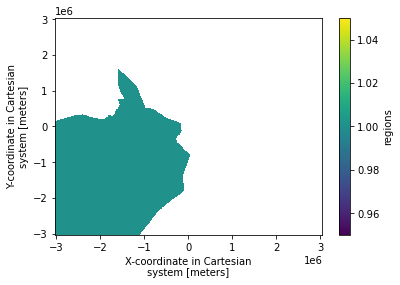

In [26]:
a = xr.where(sectFrame.regions == 1, 1, np.nan)
a.plot()

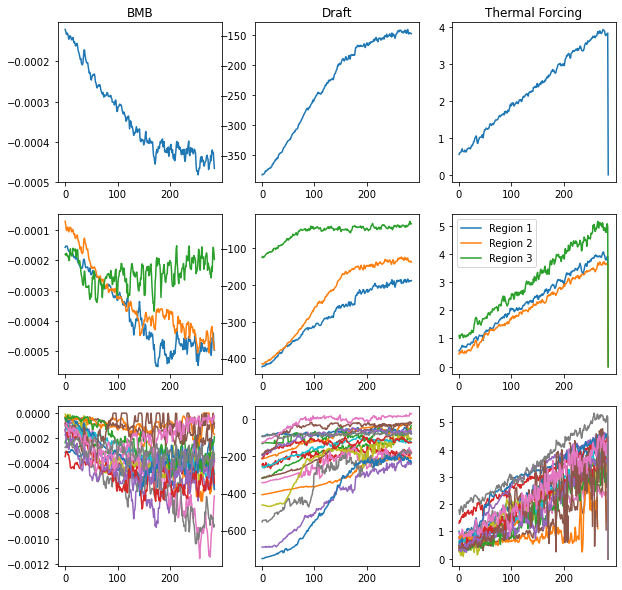

In [43]:
# Plot
fig,ax = plt.subplots(3,3, figsize=(10,10))

ax[0,0].plot(ds_bmb.groundingline_bmb_antarctica)
ax[0,1].plot(ds_draft.groundingline_depth_antarctica)
ax[0,2].plot(ds_tf.groundingline_thermal_forcing_antarctica)

for reg in regNums:
    ax[1,0].plot(ds_bmb[f'groundingline_bmb_region{reg}'],label=f'Region {reg}')
    ax[1,1].plot(ds_draft[f'groundingline_depth_region{reg}'],label=f'Region {reg}')
    ax[1,2].plot(ds_tf[f'groundingline_thermal_forcing_region{reg}'],label=f'Region {reg}')

for sec in secNums:
    ax[2,0].plot(ds_bmb[f'groundingline_bmb_sector{sec}'],label=f'Sector {sec}')
    ax[2,1].plot(ds_draft[f'groundingline_depth_sector{sec}'],label=f'Sector {sec}')
    ax[2,2].plot(ds_tf[f'groundingline_thermal_forcing_sector{sec}'],label=f'Sector {sec}')

ax[0,0].set_title('BMB')
ax[0,1].set_title('Draft')
ax[0,2].set_title('Thermal Forcing')

ax[1,2].legend()





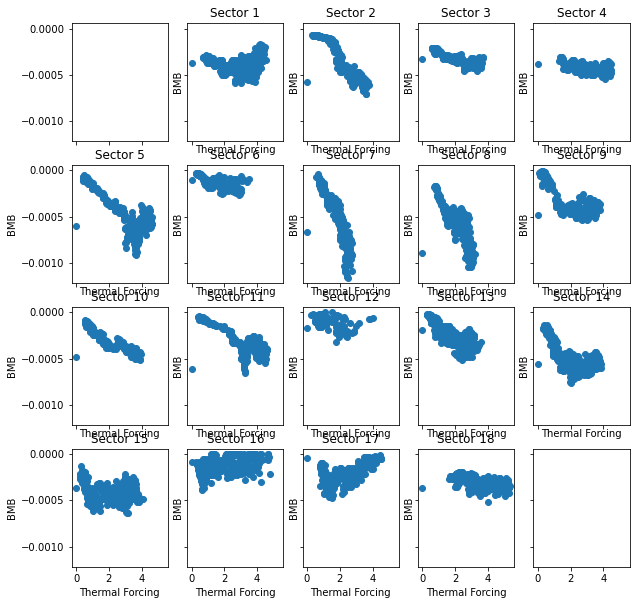

In [45]:
# For each of the 18 sectors, plot a scatter plot of bmb vs thermal forcing

fig,ax = plt.subplots(4,5, figsize=(10,10), sharex=True, sharey=True)


# unravel axes
ax = ax.ravel()



for sec in secNums:
    ax[sec].scatter(ds_tf[f'groundingline_thermal_forcing_sector{sec}'],ds_bmb[f'groundingline_bmb_sector{sec}'])
    ax[sec].set_title(f'Sector {sec}')
    ax[sec].set_ylabel('BMB')
    ax[sec].set_xlabel('Thermal Forcing')

